In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

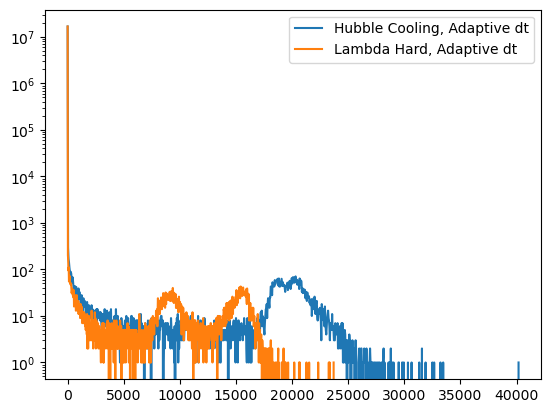

In [4]:
array_dict = {}

array_dict['base'] = ["./data/output_base_10.npy", "Hubble Cooling, Adaptive dt"]
#array_dict['reduced'] = ["./data/output_reduced_10.npy", "Reduced, Adaptive dt"]
#array_dict['shifted'] = ["data/output_shifted_10.npy", "Shifted, Adaptive dt"]
#array_dict['helium'] = ["data/output_helium_10.npy", "Helium, Adaptive dt"]
#array_dict['lambda0'] = ["data/output_lambda0_10.npy", "Lambda Hard, Adaptive dt"]
#array_dict['lambda'] = ["data/output_lambda_10.npy", "Lambda, Adaptive dt"]
array_dict['ramses_lambda0'] = ["data/output_ramses_lambda_10.npy", "Lambda Hard, Adaptive dt"]

for key, array in array_dict.items():
    data = np.load(array[0])
    label = array[1]
    plt.plot(data[1], data[0], label=label)

    #plt.axis([1.e1,3.e5,1.e0,1e8])
    plt.legend(loc=1)
    #plt.loglog()
    plt.semilogy()
    #plt.title(r'${\rm Hydrogen}\;{\rm Fraction}$', fontsize=24)
#plt.savefig("phase_combined.png")
plt.show()
plt.close()

In [3]:
arg = 10

fold = "../hydrogen/"
arr_h = np.fromfile(fold+"xhi%03d.bin" % arg, dtype=np.double)
DIMX = int((arr_h.size+1)**(1.0/3.0))
print("<x_hii> = {}".format(np.sum(arr_h)/(DIMX)**3))
#arr[arr<1.e-6] = 1.e-6
arr_h = 1.0 - arr_h
arr_h = arr_h.reshape(DIMX,DIMX,DIMX)
arr_h = np.swapaxes(arr_h, 0, 2)

fold = "../photons/"
arr_energy = np.fromfile(fold+"temp%03d.bin" % arg, dtype=np.float32)
#arr_energy = arr_energy - 10000
print("<energy> = {}".format(np.sum(arr_energy)/(DIMX)**3))
arr_energy = arr_energy.reshape(DIMX,DIMX,DIMX)
arr_energy = np.swapaxes(arr_energy, 0, 2)

fold = "../../../nanoJubilee/GridDensities/256/"
arr_n = np.fromfile(fold + "GridDensities_256_%03d.bin" % int(arg/10), dtype=np.float32)
print("<n> = {}".format(np.sum(arr_n)/(DIMX)**3))
arr_n = arr_n.reshape(DIMX,DIMX,DIMX)
arr_n = np.swapaxes(arr_n, 0, 2)

<x_hii> = 0.00028552428822406674
<energy> = 14.418307304382324
<n> = 0.9999997615814209


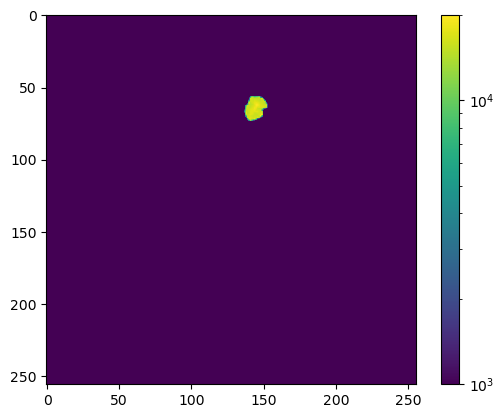

In [4]:
im = plt.imshow(arr_energy[:,:,200],norm=matplotlib.colors.LogNorm(vmax=2e4, vmin=1e3))
plt.colorbar(im)

(array([[10.,  0.,  0., ...,  0.,  0.,  0.],
        [19.,  0.,  0., ...,  0.,  0.,  0.],
        [49.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 1.,  0.,  0., ...,  0.,  0.,  0.],
        [ 1.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]),
 array([-0.48895437, -0.47506607, -0.46117777, -0.44728948, -0.43340118,
        -0.41951288, -0.40562459, -0.39173629, -0.37784799, -0.3639597 ,
        -0.3500714 , -0.3361831 , -0.32229481, -0.30840651, -0.29451821,
        -0.28062992, -0.26674162, -0.25285333, -0.23896503, -0.22507673,
        -0.21118844, -0.19730014, -0.18341184, -0.16952355, -0.15563525,
        -0.14174695, -0.12785866, -0.11397036, -0.10008206, -0.08619377,
        -0.07230547, -0.05841717, -0.04452888, -0.03064058, -0.01675228,
        -0.00286399,  0.01102431,  0.0249126 ,  0.0388009 ,  0.0526892 ,
         0.06657749,  0.08046579,  0.09435409,  0.10824238,  0.12213068,
         0.13601898,  0.14990727,  0.16379557,  0.17768387

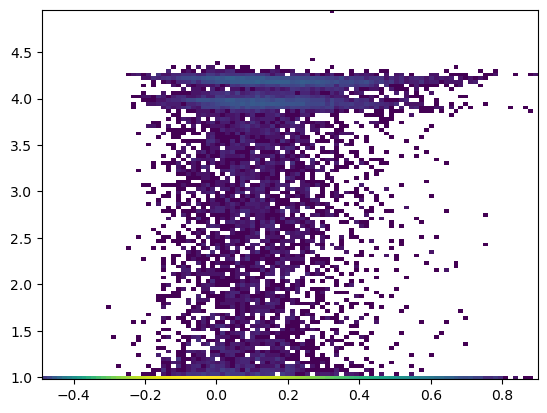

In [5]:
plt.hist2d(np.log10(arr_n.flatten()), np.log10(arr_energy.flatten()), bins=100, norm=matplotlib.colors.LogNorm())
#plt.axis([1.e1,3.e5,1.e0,1e8])

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants, integrate

#spectral slope of g_nu = # of photons (not energy of photons)
alp=-2.45
evtonu=2.3988e14

def g_nu(nu):
    cut=45.0
    g=np.where(nu/evtonu<cut, (nu/evtonu/cut)**alp, 0.1)
    g=np.where(nu/evtonu<70, g, 0.0)
    return g

/tmp/ipykernel_261150/841660048.py:12: RuntimeWarning: invalid value encountered in divide
  sig_h=a0*(nuih/nu)**4*np.exp(4.0-(4.0*np.arctan(par)/par))/(1.-np.exp(-2.0*np.pi/par))
/tmp/ipykernel_261150/841660048.py:12: RuntimeWarning: divide by zero encountered in divide
  sig_h=a0*(nuih/nu)**4*np.exp(4.0-(4.0*np.arctan(par)/par))/(1.-np.exp(-2.0*np.pi/par))
/tmp/ipykernel_261150/841660048.py:11: RuntimeWarning: invalid value encountered in sqrt
  par=np.where(nu > nuih, np.sqrt(nu/nuih-1.e0), 0.0)


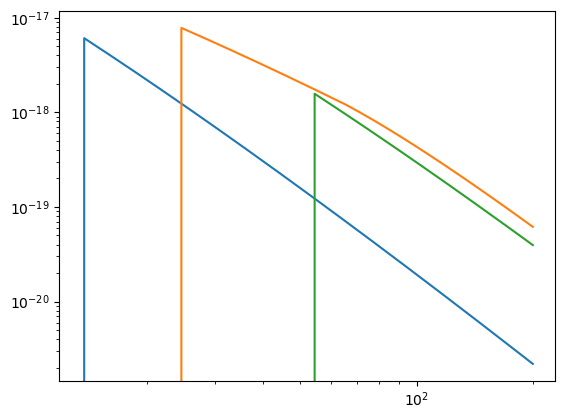

In [43]:
#------------------------------------------------------------------------
def sig_h(nu):
#
#  ...H CROSS SECTION [CM2]
#
      nuih=13.6*evtonu
#     [cm2]
      a0=6.3e-18                          
      sig_h=a0

      par=np.where(nu > nuih, np.sqrt(nu/nuih-1.e0), 0.0)
      sig_h=a0*(nuih/nu)**4*np.exp(4.0-(4.0*np.arctan(par)/par))/(1.-np.exp(-2.0*np.pi/par))
      sig_h=np.where(nu > nuih, sig_h, 0.0) 

      return sig_h
#------------------------------------------------------------------------

def sig_he(nu):
#
#  ...He CROSS SECTION [CM2], FROM BROWN FORMULA
#
      nuih=13.6*evtonu
      a0=6.3e-18 
      sig_he=np.where(nu > 24.6*evtonu, sig_h(nu)*(6.53*(nu/evtonu/24.6)-0.22), 0.0)
      # Original version
      #sig_he=np.where(nu > 65.4*evtonu, sig_h(nu)*(37.0-19.1*(nu/evtonu/65.4)**(-0.76)),sig_he)
      # MR modification to have a smooth connection at 65.4: 17.14024390
      sig_he=np.where(nu > 65.4*evtonu, sig_h(nu)*(36.2402439-19.1*(nu/evtonu/65.4)**(-0.76)),sig_he)

      return sig_he
#------------------------------------------------------------------------

def sig_hep(nu):
#
#  ...HE+ CROSS SECTION [CM2]
#
      sig_hep=sig_h(nu/4.0)/4.0
      sig_hep=np.where(nu < 54.4*evtonu, 0.0, sig_hep) 

      return sig_hep
#------------------------------------------------------------------------
def ge_nu(nu):
    return g_nu(nu)*(nu/evtonu)
#------------------------------------------------------------------------
def int1(nu):
    return g_nu(nu)*sig_h(nu)
def int2(nu):
    return g_nu(nu)*sig_he(nu)
def int3(nu):
    return g_nu(nu)*sig_hep(nu)
def int1e(nu):
    return g_nu(nu)*sig_h(nu)*(nu/evtonu-13.6)
#------------------------------------------------------------------------

x=np.linspace(13.6, 200, 1000)
nu=x*evtonu
plt.plot(x,sig_h(nu))
plt.plot(x,sig_he(nu))
plt.plot(x,sig_hep(nu))
plt.xscale('log')
plt.yscale('log')

In [44]:
integrator = integrate.quad # trap/simp/trap_scipy/simp_scipy/integrate.quad
#integrals:
# sgn=int sig*g_nu dn/(int g_nu du)
# sge=int sig*g_nu dn/(int g_nu du)
# heating: X=int sig*g_nu*(h*nu-13.6) dnu/(int sig*g_nu dnu)

e1=13.6*evtonu
e2=24.59*evtonu
e3=54.42*evtonu
e4=200.0*evtonu
g1, err = integrator(g_nu, e1, e2)
g2, err = integrator(g_nu, e2, e3)
g3, err = integrator(g_nu, e3, e4)
gt=g1+g2+g3
sh1, err = integrator(int1, e1, e2)
sh2, err = integrator(int1, e2, e3)
sh3, err = integrator(int1, e3, e4)

eh1, err = integrator(int1e, e1, e2)
eh2, err = integrator(int1e, e2, e3)
eh3, err = integrator(int1e, e3, e4)

ge1, err = integrator(ge_nu, e1, e2)
ge2, err = integrator(ge_nu, e2, e3)
ge3, err = integrator(ge_nu, e3, e4)

egy1=ge1/g1
egy2=ge2/g2
egy3=ge3/g3
get=ge1+ge2+ge3

# fphotons*Ntot, fenergy*Etot av_en=fenergy/fphotons *Etot/Ntot
print('Integrator:', integrator)
print(f'csn = {sh1/g1:.3e} cm^2, g1 = {g1/gt:.3f}, X1 = {eh1/sh1:.1f} eV, egy = {egy1:.1f} eV.')
print(f'csn = {sh2/g2:.3e} cm^2, g2 = {g2/gt:.3f}, X2 = {eh2/sh2:.1f} eV, egy = {egy2:.1f} eV.')
print(f'csn = {sh3/g3:.3e} cm^2, g3 = {g3/gt:.3f}, X3 = {eh3/sh3:.1f} eV, egy = {egy3:.1f} eV.')
print('ionization rate: tau_HI=csn*N_HI')
print('Heating rate: Gamma_heat=Gamma_ion*X [eV/s]')

'''
X=23.0
print(f' ge1 = {ge1/get:.3f}, X1 = {X*egy1*gt/get:.1f} eV, egy = {egy1:.1f} eV.')
print(f' ge2 = {ge2/get:.3f}, X2 = {X*egy2*gt/get:.1f} eV, egy = {egy2:.1f} eV.')
print(f' ge3 = {ge3/get:.3f}, X3 = {X*egy3*gt/get:.1f} eV, egy = {egy3:.1f} eV.')
'''
plt.show()

Integrator: <function quad at 0x7f7992ac5620>
csn = 3.487e-18 cm^2, g1 = 0.688, X1 = 2.9 eV, egy = 17.8 eV.
csn = 6.510e-19 cm^2, g2 = 0.302, X2 = 16.4 eV, egy = 32.7 eV.
csn = 8.482e-20 cm^2, g3 = 0.011, X3 = 47.6 eV, egy = 62.2 eV.
ionization rate: tau_HI=csn*N_HI
Heating rate: Gamma_heat=Gamma_ion*X [eV/s]


In [38]:
#alp=-0.45
alp=-2.45
evtonu=2.3988e14

def angstrom(nu):
    return 12398.7/nu
def ev(lamb):
    return 12398.7/lamb

def g_nu(nu):
    cut=45.0
    g=np.where(nu/evtonu<cut, (nu/evtonu/cut)**alp, 0.1)
    g=np.where(nu/evtonu<70, g, 0.0)
    return g

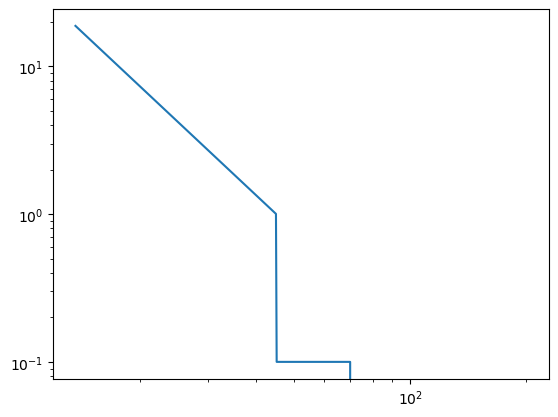

In [39]:
x=np.linspace(13.6, 200, 1000)
nu=x*evtonu
plt.plot(x,g_nu(nu))
#plt.plot(x,sig_he(nu))
#plt.plot(x,sig_hep(nu))
plt.xscale('log')
plt.yscale('log')

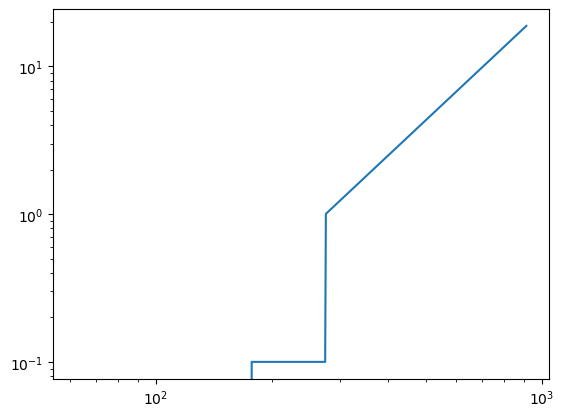

In [40]:
x_angs = wavelength(x)

plt.plot(x_angs,g_nu(evtonu*energy(x_lamb)))
plt.xscale('log')
plt.yscale('log')

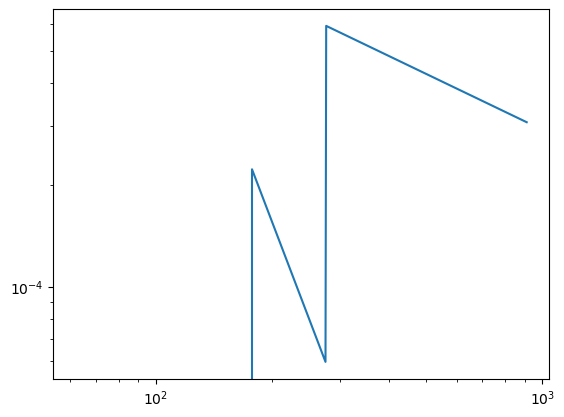

In [41]:
x_angs = wavelength(x)

plt.plot(x_angs,(x_angs)**(-2)*ge_nu(evtonu*energy(x_lamb)))
plt.xscale('log')
plt.yscale('log')